In [6]:
from functools import partial
from typing import Union

import os

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from tqdm import tqdm

import sys
sys.path.append('../../utils')
sys.path.append('../../data')
sys.path.append('../../models')

from cg import conjugate_gradient
from data_utils import batch_data
from jacobian_tools import flatten_jacobian
from model_utils import create_train_state
from MLP import MLP_1D
from plotting import plot_results
from matplotlib import pyplot as plt
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


In [7]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
# y = jnp.sin(1 * jnp.pi * x) + 5 * jnp.sin(5 * jnp.pi * x + 2) + 7 * jnp.sin(7 * jnp.pi * x - 1) + 7 * jnp.sin(10 * jnp.pi * x + .2)
# y = jnp.sin(1 * jnp.pi * x) + jnp.sin(5 * jnp.pi * x + 2) + 7 * jnp.sin(7 * jnp.pi * x - 1) + 7 * jnp.sin(10 * jnp.pi * x + .2)
y = jnp.zeros_like(x)
n = 3
for k in range(1, n + 1):
    y += k / n * jnp.sin((2 * k + 1) * jnp.pi * x - k)


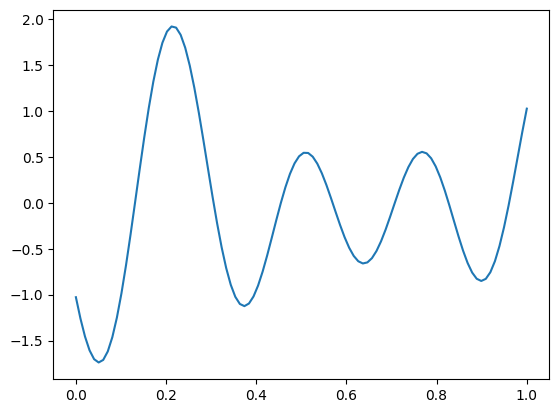

In [9]:
plt.plot(x, y)

In [10]:
from run_exp import *

In [15]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='gn-exact', 
)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_gn = train_model(state, x, y, num_iterations=50000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=100
                                    )


  0%|          | 0/50000 [00:00<?, ?it/s]

Running gn-exact


100%|██████████| 50000/50000 [09:22<00:00, 88.87it/s]


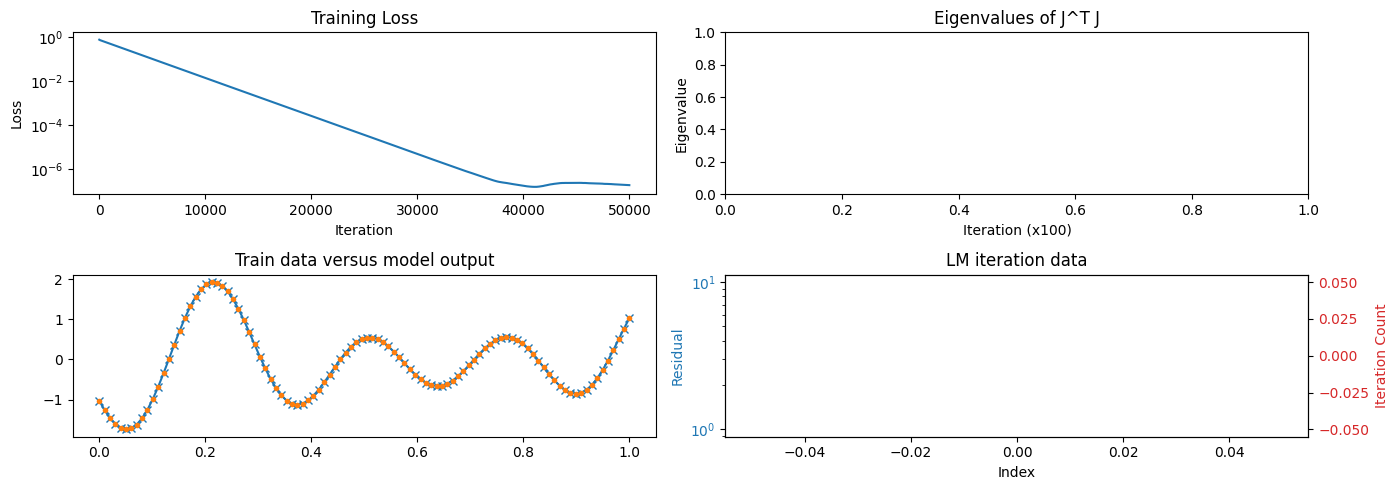

In [16]:
plot_results(state, metrics_history_gn, x, y)
plt.show()


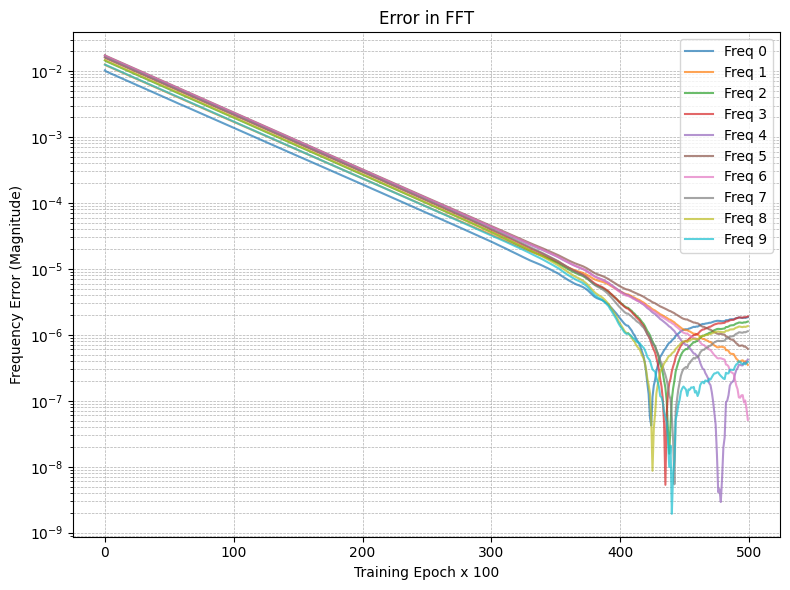

In [54]:
n = len(y)
all_fft = []
for est in metrics_history_gn['prediction']:
    fft_err = jnp.fft.fft(y - est) / n
    fft_err = fft_err[:n // 2]
    fft_err = jnp.abs(fft_err)
    all_fft.append(fft_err.flatten())
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
model = MLP_1D(num_layers=2,hidden_dim=80)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_sgd = train_model(state, x, y, num_iterations=50000, obtain_matrices=False, 
                                    lm_schedule=None, batch_size=100
                                    )


100%|██████████| 50000/50000 [02:45<00:00, 302.85it/s]


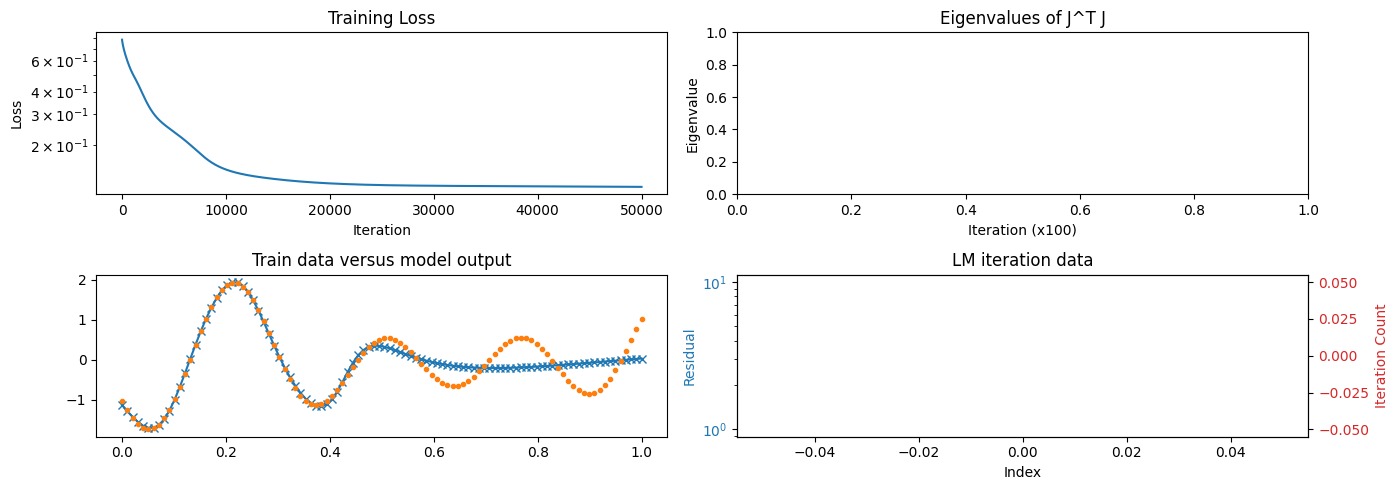

In [20]:
plot_results(state, metrics_history_sgd, x, y)
plt.show()


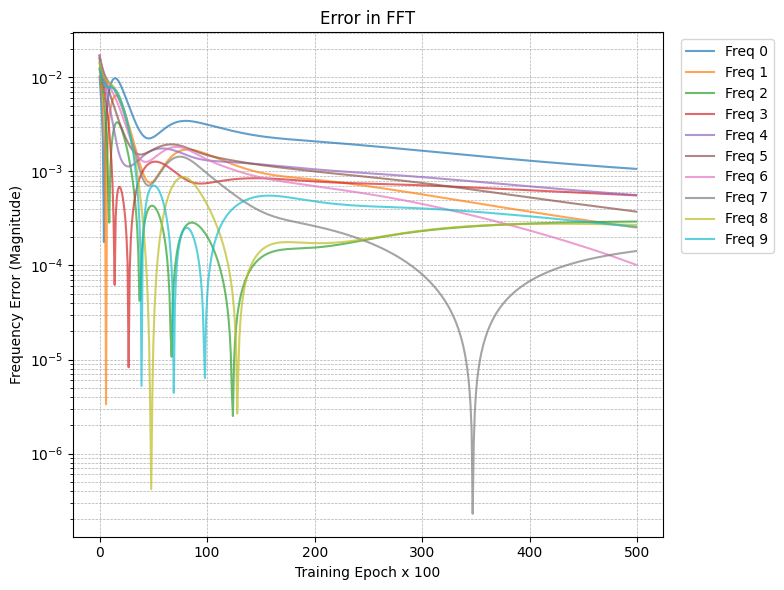

In [45]:
n = len(y)
all_fft = []
for est in metrics_history_sgd['prediction']:
    fft_err = jnp.fft.fft(y - est) / n
    fft_err = fft_err[:n // 2]
    fft_err = jnp.abs(fft_err)
    all_fft.append(fft_err.flatten())
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()

In [23]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_lm = train_model(state, x, y, num_iterations=50000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=100
                                    )


  0%|          | 0/50000 [00:00<?, ?it/s]

Running smw


100%|██████████| 50000/50000 [02:52<00:00, 289.66it/s]


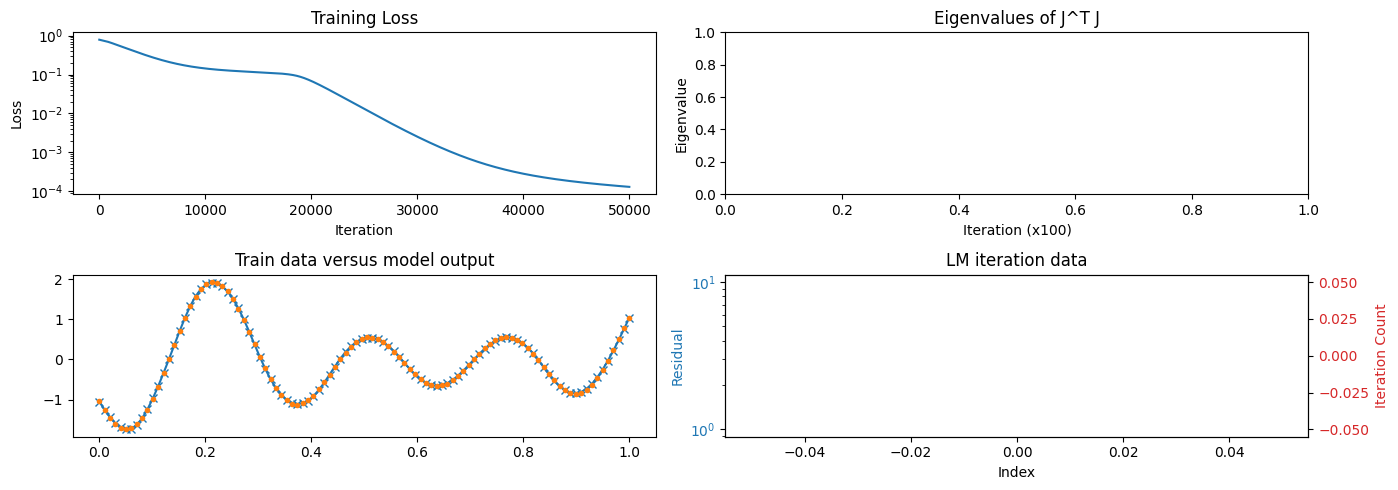

In [24]:
plot_results(state, metrics_history_lm, x, y)
plt.show()


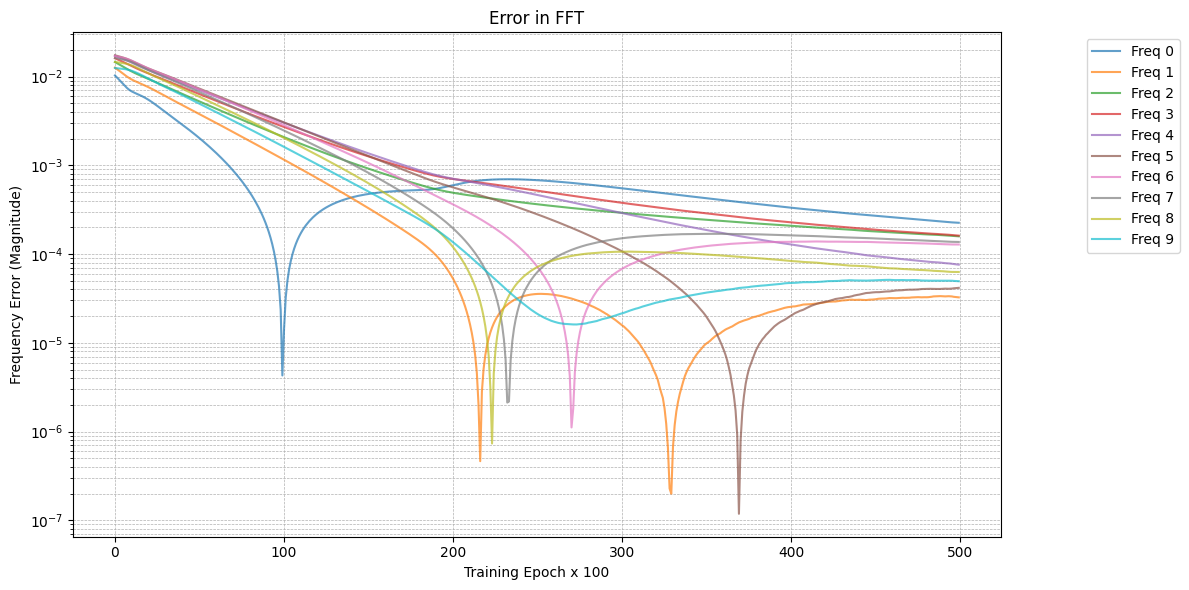

In [38]:
n = len(y)
all_fft = []
for est in metrics_history_lm['prediction']:
    fft_err = jnp.fft.fft(y - est) / n
    fft_err = fft_err[:n // 2]
    fft_err = jnp.abs(fft_err)
    all_fft.append(fft_err.flatten())
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(12, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()

In [30]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=5e-1,
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_lm_5 = train_model(state, x, y, num_iterations=50000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=100
                                    )


  0%|          | 0/50000 [00:00<?, ?it/s]

Running smw


100%|██████████| 50000/50000 [02:51<00:00, 291.13it/s]


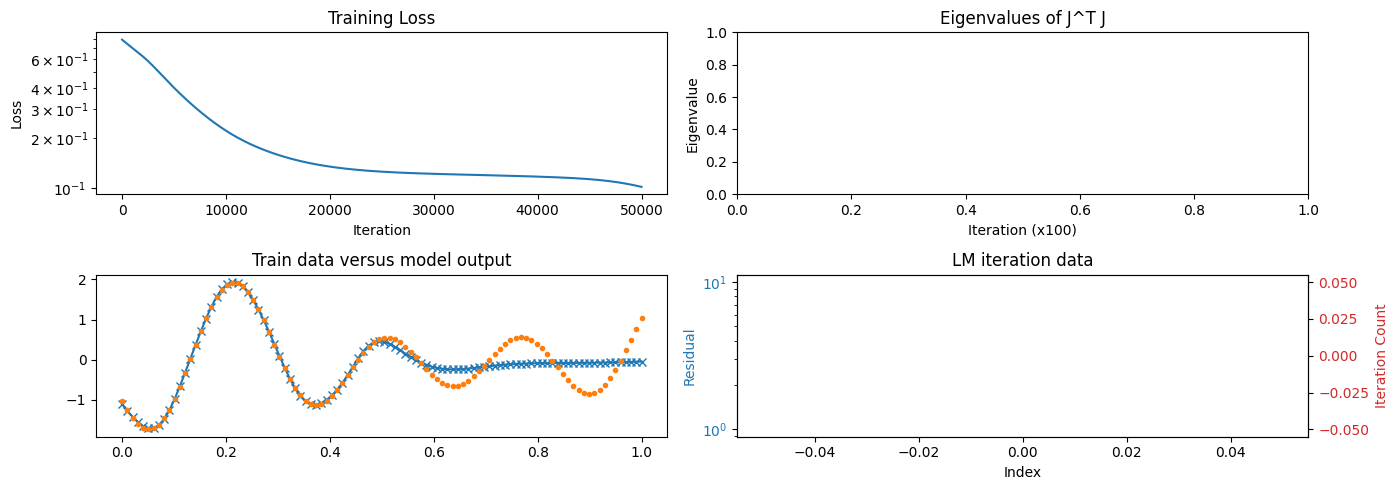

In [31]:
plot_results(state, metrics_history_lm_5, x, y)
plt.show()


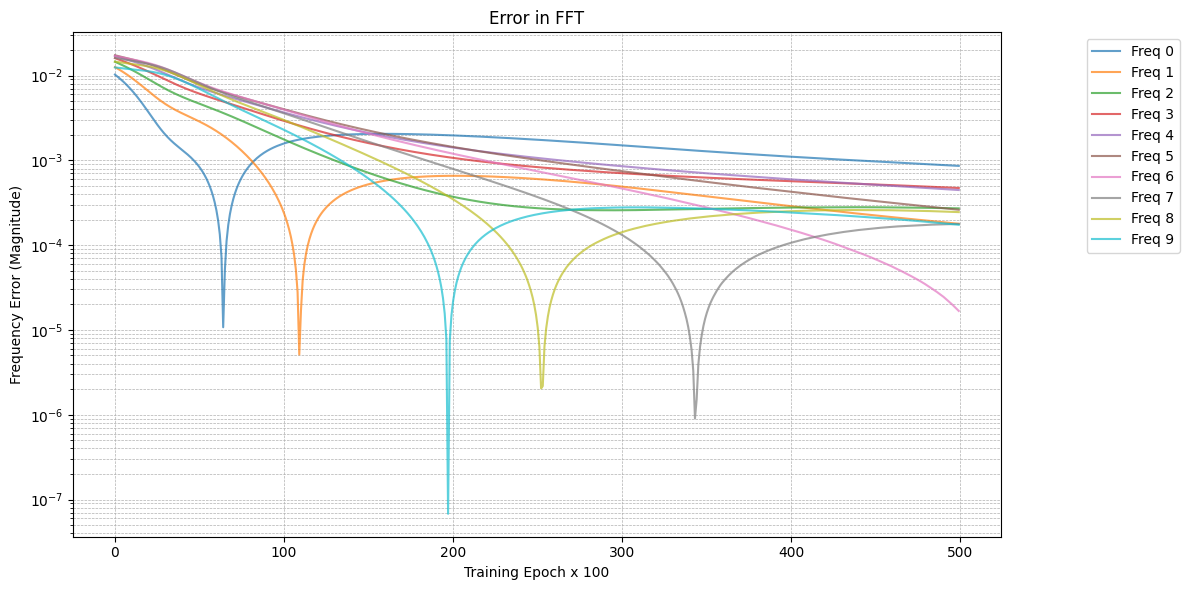

In [37]:
n = len(y)
all_fft = []
for est in metrics_history_lm_5['prediction']:
    fft_err = jnp.fft.fft(y - est) / n
    fft_err = fft_err[:n // 2]
    fft_err = jnp.abs(fft_err)
    all_fft.append(fft_err.flatten())
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(12, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()

In [33]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-2,
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_lm_01 = train_model(state, x, y, num_iterations=50000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=100
                                    )


  0%|          | 0/50000 [00:00<?, ?it/s]

Running smw


100%|██████████| 50000/50000 [02:54<00:00, 286.57it/s]


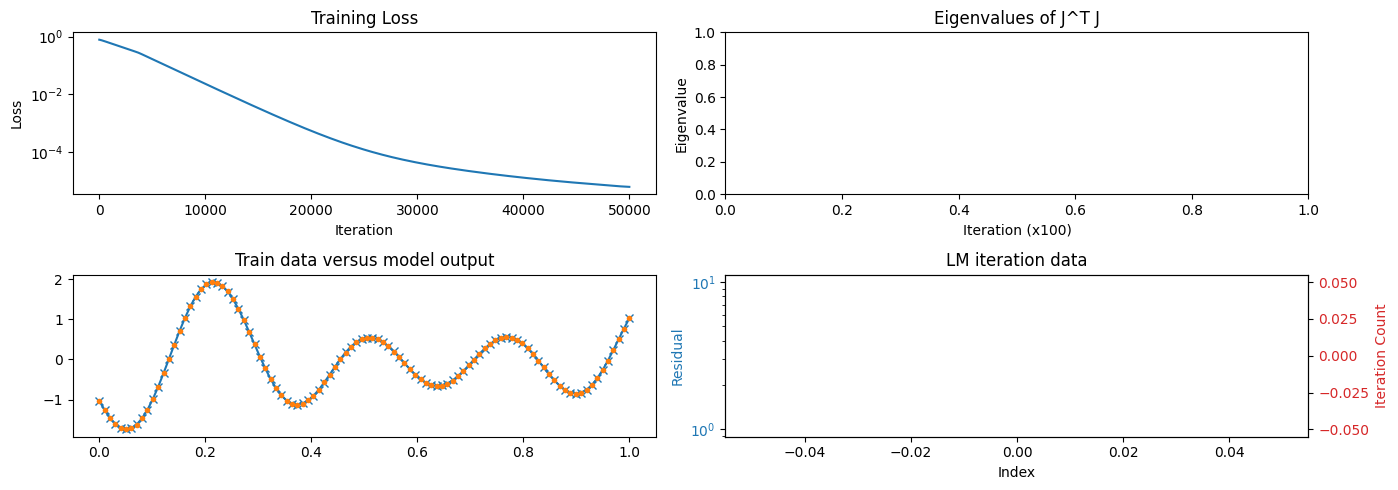

In [34]:
plot_results(state, metrics_history_lm_01, x, y)
plt.show()


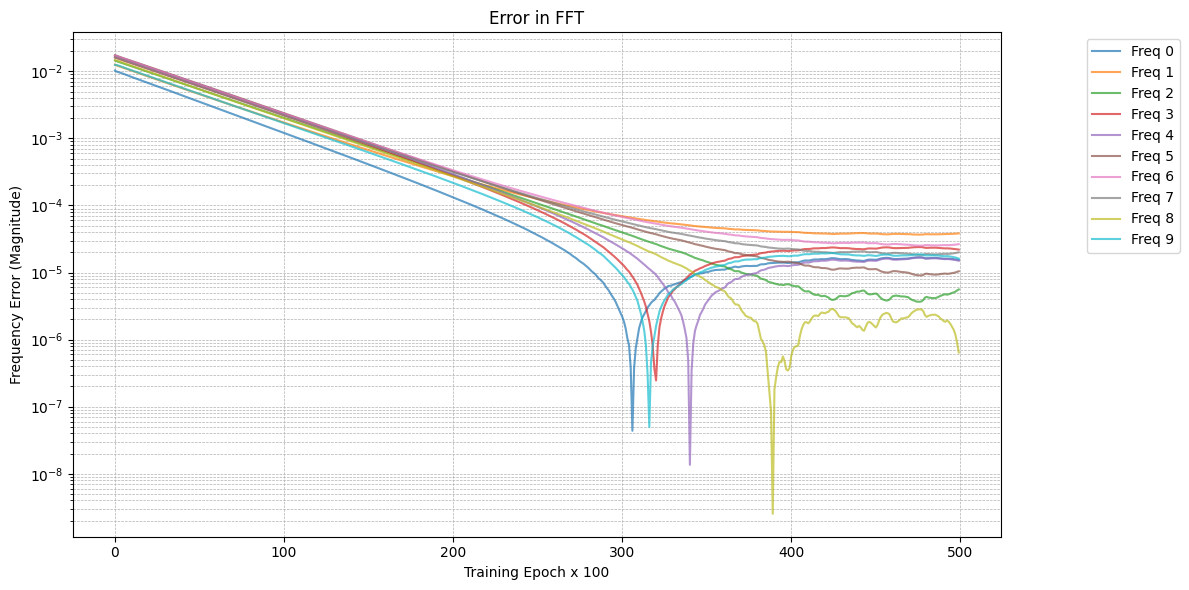

In [36]:
n = len(y)
all_fft = []
for est in metrics_history_lm_01['prediction']:
    fft_err = jnp.fft.fft(y - est) / n
    fft_err = fft_err[:n // 2]
    fft_err = jnp.abs(fft_err)
    all_fft.append(fft_err.flatten())
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(12, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()

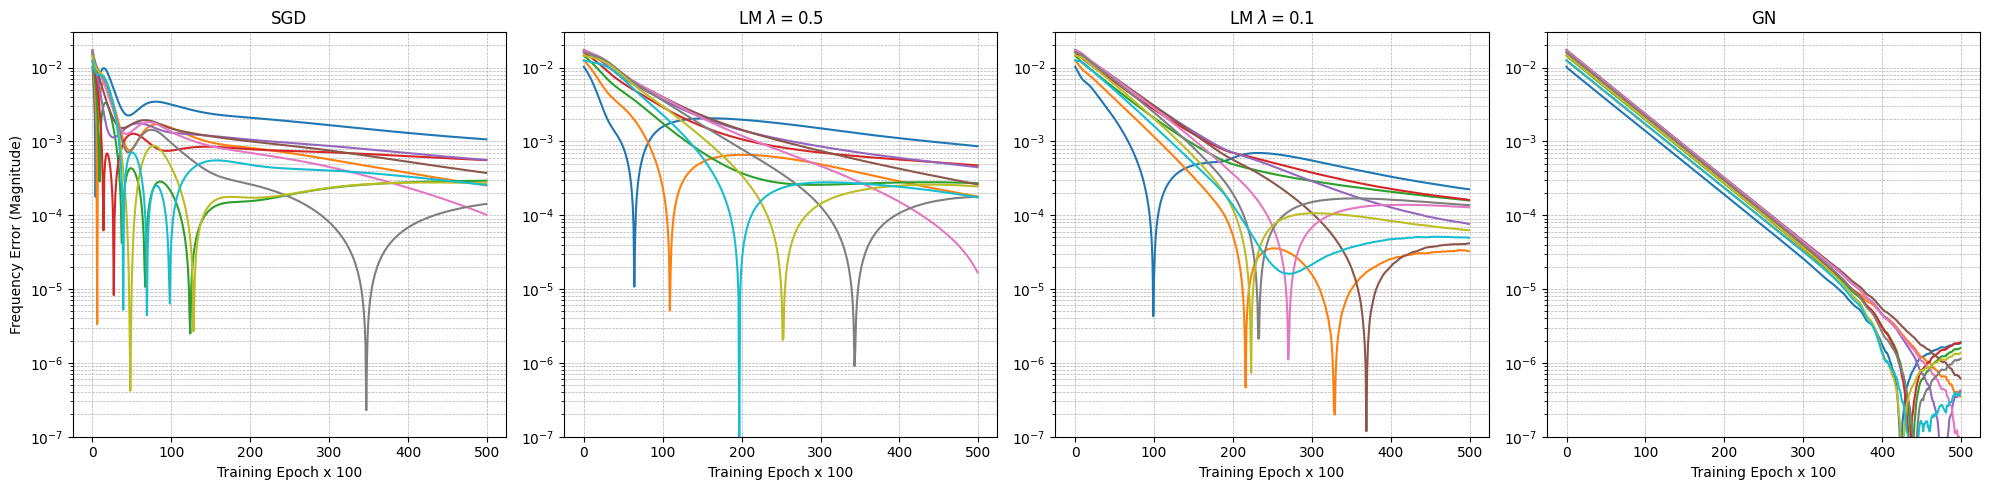

In [ ]:
# Create subfigures
fig, subfigs = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns

metrics_histories = [metrics_history_sgd, metrics_history_lm_5, metrics_history_lm, metrics_history_gn]
names = ['SGD', 'LM $\lambda=0.5$', 'LM $\lambda=0.1$', 'GN']
for idx, metrics_history in enumerate(metrics_histories):
    n = len(y)
    all_fft = []
    
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        all_fft.append(fft_err.flatten())
    
    all_fft = jnp.array(all_fft).T

    # Limit the number of frequencies to plot
    num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

    for i in range(num_frequencies_to_plot):
        subfigs[idx].semilogy(all_fft[i], label=f'Freq {i}', alpha=1)  # Use alpha for transparency

    subfigs[idx].set_title(f'{names[idx]}')
    subfigs[idx].set_xlabel('Training Epoch x 100')
    if idx == 0:
        subfigs[idx].set_ylabel('Frequency Error (Magnitude)')
    subfigs[idx].grid(True, which='both', linestyle='--', linewidth=0.5)
    subfigs[idx].set_ylim(1e-7, 3e-2)
    # subfigs[idx].legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside

plt.tight_layout()
plt.savefig('ex_1.png')
plt.show()